In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("exchange_rate.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')


# Set as index
df.set_index('date', inplace=True)
print(df.head())
print(df.info())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None


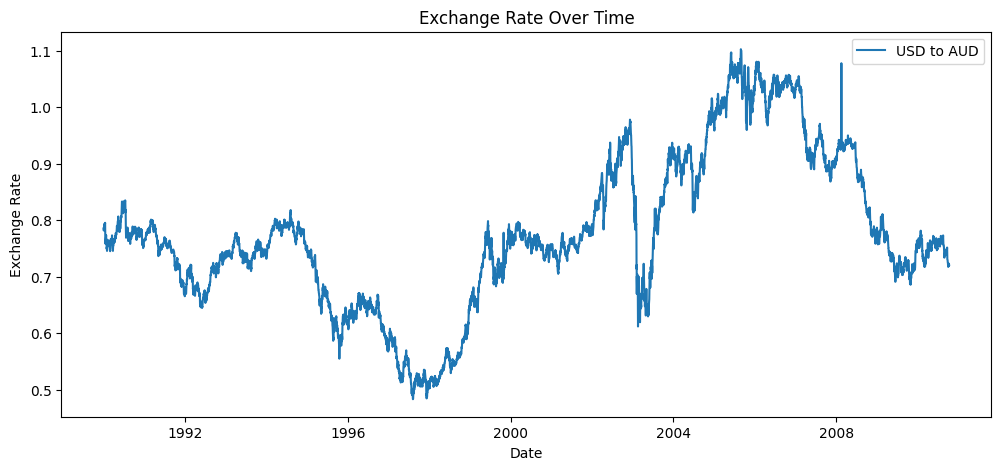

In [2]:
#Plot time series
plt.figure(figsize=(12,5))
plt.plot(df.iloc[:,0], label='USD to AUD')
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [3]:
print(df.isnull().sum())
df = df.fillna(method='ffill')

Ex_rate    0
dtype: int64


C:\Users\SUGANYA P\AppData\Local\Temp\ipykernel_18800\3667842599.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [4]:
#ARIMA model
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


In [5]:
df_diff = df.diff().dropna()

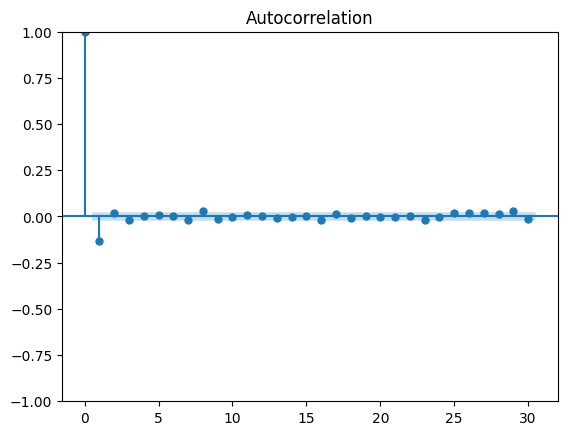

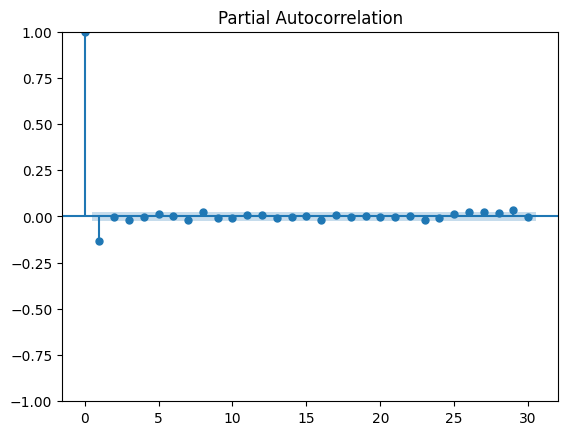

In [6]:
#ACF & PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff.iloc[:,0], lags=30)
plot_pacf(df_diff.iloc[:,0], lags=30)
plt.show()

In [7]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [8]:
#Fit ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))  # adjust based on ACF/PACF
model_fit = model.fit()

print(model_fit.summary())

E:\Users\SUGANYA P\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Users\SUGANYA P\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Users\SUGANYA P\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 03 May 2026   AIC                         -45432.092
Time:                        22:16:29   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

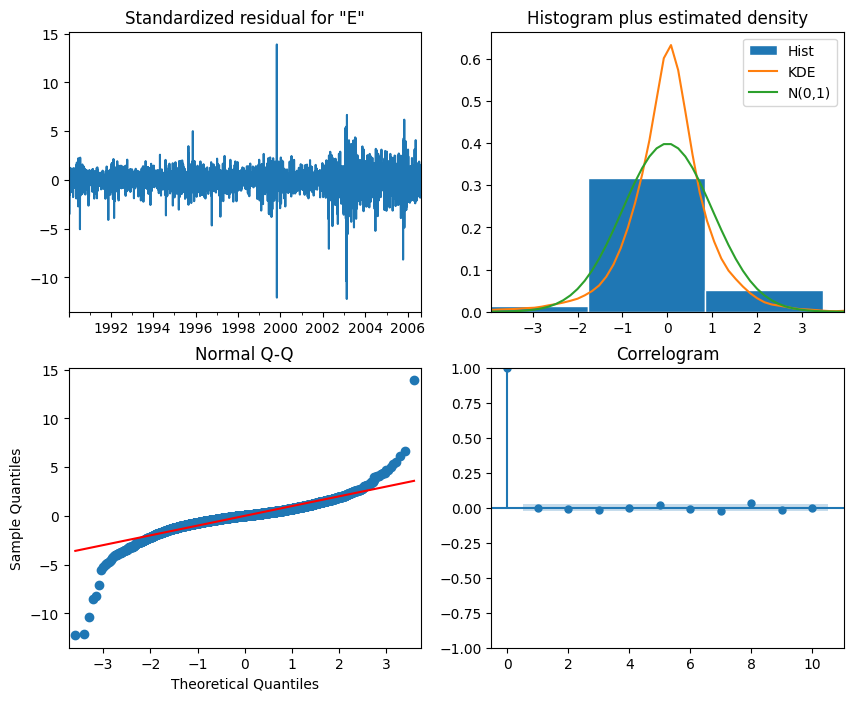

In [9]:
#Diagnostics
model_fit.plot_diagnostics(figsize=(10,8))
plt.show()

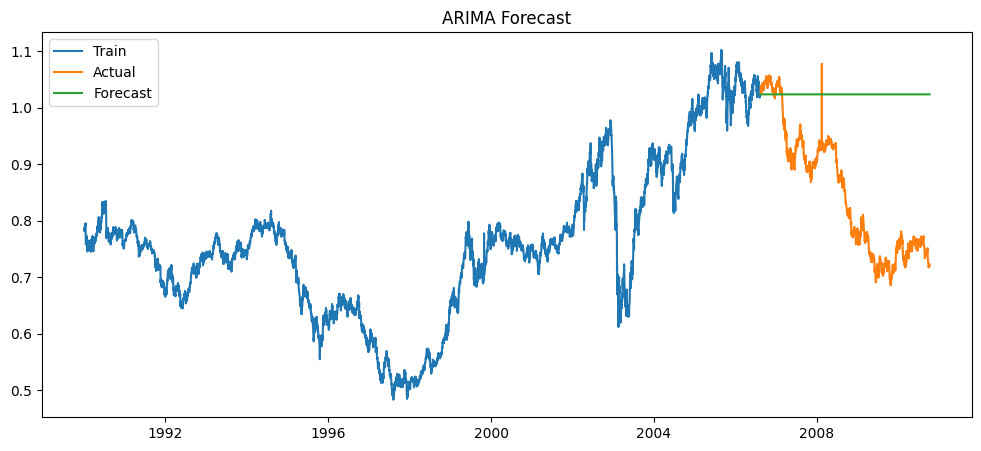

In [10]:
#Forecast
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [11]:
#Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(train, trend='add', seasonal=None)
model_es_fit = model_es.fit()

E:\Users\SUGANYA P\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


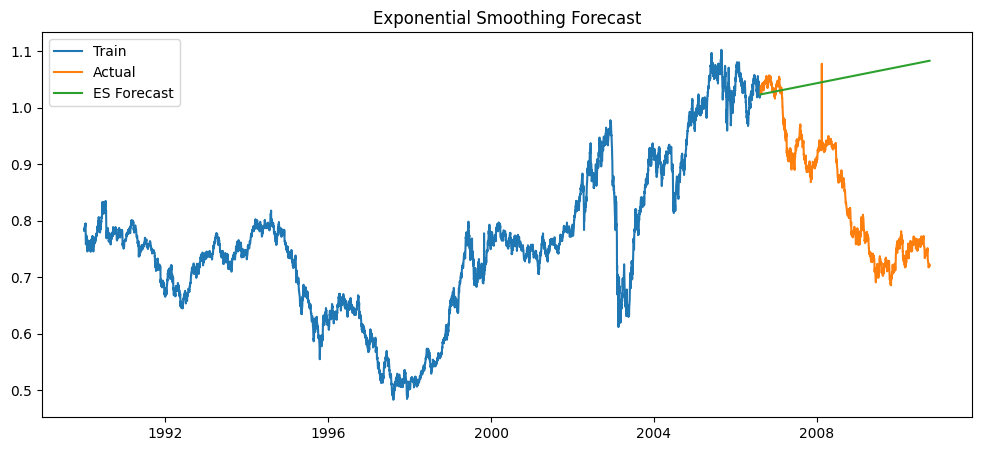

In [12]:
forecast_es = model_es_fit.forecast(len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_es, label='ES Forecast')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

In [13]:
#Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ARIMA
mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))
mape_arima = mape(test.values, forecast.values)

# ES
mae_es = mean_absolute_error(test, forecast_es)
rmse_es = np.sqrt(mean_squared_error(test, forecast_es))
mape_es = mape(test.values, forecast_es.values)

print("ARIMA -> MAE:", mae_arima, "RMSE:", rmse_arima, "MAPE:", mape_arima)
print("ES -> MAE:", mae_es, "RMSE:", rmse_es, "MAPE:", mape_es)

ARIMA -> MAE: 0.17770970449120707 RMSE: 0.20543669659668565 MAPE: 22.79797015332956
ES -> MAE: 0.20659618790631418 RMSE: 0.23910442784976926 MAPE: 26.03528638714349


In [14]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [mae_arima, mae_es],
    'RMSE': [rmse_arima, rmse_es],
    'MAPE': [mape_arima, mape_es]
})

print(comparison)

                   Model       MAE      RMSE       MAPE
0                  ARIMA  0.177710  0.205437  22.797970
1  Exponential Smoothing  0.206596  0.239104  26.035286


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam

def build_lstm(units=50, lr=0.001):
    model = Sequential()
    model.add(LSTM(units, activation='relu',
                   input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [16]:
configs = [
    {'units': 32, 'lr': 0.01, 'batch_size': 16},
    {'units': 50, 'lr': 0.001, 'batch_size': 32},
    {'units': 64, 'lr': 0.0005, 'batch_size': 64}
]

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

In [21]:
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 10)

In [23]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [25]:
print(X_train.shape)

(6062, 10, 1)


In [30]:
for config in configs:
    print("Running config:", config)
    
    model = build_lstm(config['units'], config['lr'])

    model.fit(X_train, y_train,
              epochs=20,
              batch_size=config['batch_size'],
              verbose=0)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append((config, rmse))

Running config: {'units': 32, 'lr': 0.01, 'batch_size': 16}
48/48 [==============================] - 0s 2ms/step
Running config: {'units': 50, 'lr': 0.001, 'batch_size': 32}
48/48 [==============================] - 0s 2ms/step
Running config: {'units': 64, 'lr': 0.0005, 'batch_size': 64}
48/48 [==============================] - 1s 4ms/step


In [31]:
print("Results:", results)

Results: [({'units': 32, 'lr': 0.01, 'batch_size': 16}, 0.010921062460856968), ({'units': 50, 'lr': 0.001, 'batch_size': 32}, 0.011061725912195319), ({'units': 64, 'lr': 0.0005, 'batch_size': 64}, 0.01298264390998002), ({'units': 32, 'lr': 0.01, 'batch_size': 16}, 0.010945047943214771), ({'units': 50, 'lr': 0.001, 'batch_size': 32}, 0.012495251397059108), ({'units': 64, 'lr': 0.0005, 'batch_size': 64}, 0.011577843341362654)]
